In [1]:
import sys
sys.path.append('../../../')

In [2]:
from CADETProcess.processModel import ComponentSystem
component_system = ComponentSystem(2)

In [3]:
from CADETProcess.modelBuilder import CompartmentBuilder

volume = [1e-3, 2e-3, 3e-3, 4e-3, 5e-3]
flow_rate_matrix = [
    0,      0.1e-4, 0.2e-4, 0.3e-4, 0.4e-4,
    0.1e-4, 0,      0,      0,      0,
    0.2e-4, 0,      0,      0,      0,
    0.3e-4, 0,      0,      0,      0,
    0.4e-4, 0,      0,      0,      0,
]

builder_simple = CompartmentBuilder(
    component_system,
    volume, flow_rate_matrix,
)

In [4]:
volume = ['inlet', 2, 1, 3, 1, 2, 1, 4, 1, 'outlet']

flow_rate_matrix = [
#   0    1    2    3    4    5    6    7    8    9
    0,   0.1, 0,   0,   0,   0,   0,   0,   0,   0,   # 0
    0,   0,   0.3, 0,   0,   0,   0,   0.1, 0,   0,   # 1
    0,   0.1, 0,   0.1, 0,   0,   0,   0.1, 0,   0,   # 2
    0,   0.2, 0,   0,   0,   0.5, 0,   0,   0.1, 0,   # 3
    0,   0,   0,   0.1, 0,   0.1, 0,   0.1, 0,   0,   # 4
    0,   0,   0,   0,   0.3, 0,   0.2, 0.1, 0,   0,   # 5
    0,   0,   0,   0,   0,   0,   0,   0.1, 0,   0.1, # 6
    0,   0,   0,   0.5, 0,   0,   0,   0,   0,   0,   # 7
    0,   0,   0,   0.1, 0,   0,   0,   0,   0,   0,   # 8
    0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   # 9
]

builder_complex = CompartmentBuilder(
    component_system,
    volume, flow_rate_matrix,
)

In [5]:
builder_simple.init_c = 1

In [6]:
builder_simple.init_c = [0,1]

In [7]:
import numpy as np

builder_simple.init_c = np.array([
    [0,0],
    [1,1],
    [2,2],
    [3,3],
    [4,4]
])

In [8]:
builder_simple.add_tracer(4, [10, 10], 10, 0.1e-3, t_start=0)

In [9]:
from CADETProcess.processModel import MassActionLaw

reaction_model = MassActionLaw(component_system)
reaction_model.add_reaction(
    [0, 1], [-1, 1], k_fwd=2, k_bwd=1
)

builder_simple.bulk_reaction_model = reaction_model

In [10]:
builder_simple.init_c = 0

In [11]:
from CADETProcess.simulator import Cadet
process_simulator = Cadet()

process = builder_simple.process
process.cycle_time = 100

simulation_results = process_simulator.simulate(process)

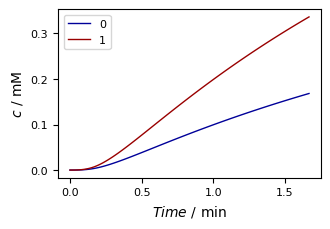

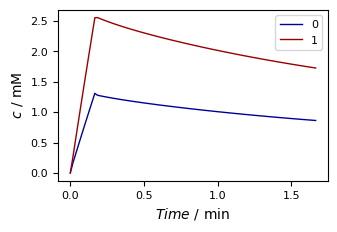

In [12]:
_ = simulation_results.solution[f'compartment_1'].outlet.plot()
_ = simulation_results.solution[f'compartment_4'].outlet.plot()